<a href="https://colab.research.google.com/github/pnrajucse/NASSCOM-AI-TRAINING/blob/main/U13_Optimization_BiasVariance_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U13 — Optimization + Bias-Variance: Lab

### Real-world brief: predicting a power plant's electrical output

A **combined-cycle power plant** generates electricity from gas + steam turbines. Its net output drifts with ambient conditions. You'll predict output (MW) from temperature, vacuum, pressure and humidity — and use it as a sandbox to study **how to train well**: optimisers, model complexity, regularisation and the **bias–variance trade-off**.

**Resource provided:** `powerplant.csv` (one row per hourly reading). Keep it beside this notebook (upload it in Colab).

_Phase D — Model Training & Optimization._

#objectives

Compare optimisers (SGD vs Adam) and see the effect of the learning rate

Watch the bias–variance trade-off emerge as model complexity grows

Use Ridge & Lasso regularisation to control overfitting

Read learning curves to diagnose high bias vs high variance

Combine the right complexity + regularisation for the lowest test error

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [20]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path="powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists('powerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [21]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)

train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


#1. A baseline linear model

In [22]:
# -----------------------------------------------------------
# 🔹 1A. FIT A PLAIN LINEAR REGRESSION AS THE BASELINE
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f'baseline RMSE: {rmse:.2f} MW | R2: {r2_score(y_test, pred):.3f}')

baseline RMSE: 3.86 MW | R2: 0.963


#2. Optimisers in action — SGD vs Adam

A neural-net regressor exposes its training loss curve, so we can literally watch different optimisers converge.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


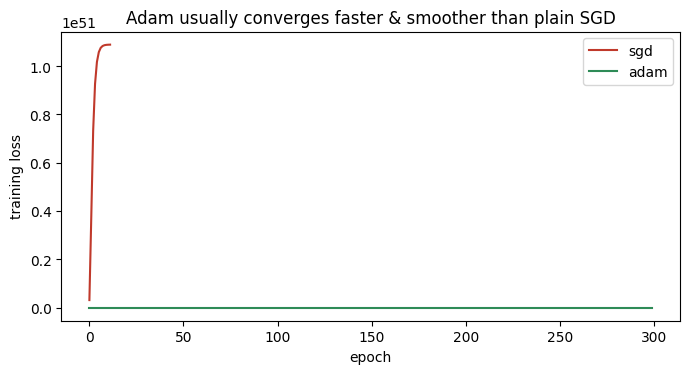

In [23]:
# -----------------------------------------------------------
# 🔹 2A. SAME MODEL, DIFFERENT OPTIMISER
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 2 — The learning rate matters
1. With `solver='sgd'`, train three networks at `learning_rate_init` = 0.001, 0.01 and 0.2.
2. Plot all three `loss_curve_`s on one axis.
3. In a comment, say which is too slow, which is good, and which is unstable.

In [28]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)

train: (1500, 4) | test: (500, 4)


In [29]:
print(df.columns.tolist())

['AT', 'V', 'AP', 'RH', 'PE']


Columns in dataset:
['AT', 'V', 'AP', 'RH', 'PE']

Feature matrix shape: (2000, 4)
Target vector shape : (2000,)
Training failed:
ValueError
Unknown label type: (array([459.94, 427.94, 439.5 , ..., 462.44, 482.79, 428.81]),)


/tmp/ipykernel_3601/3491568136.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


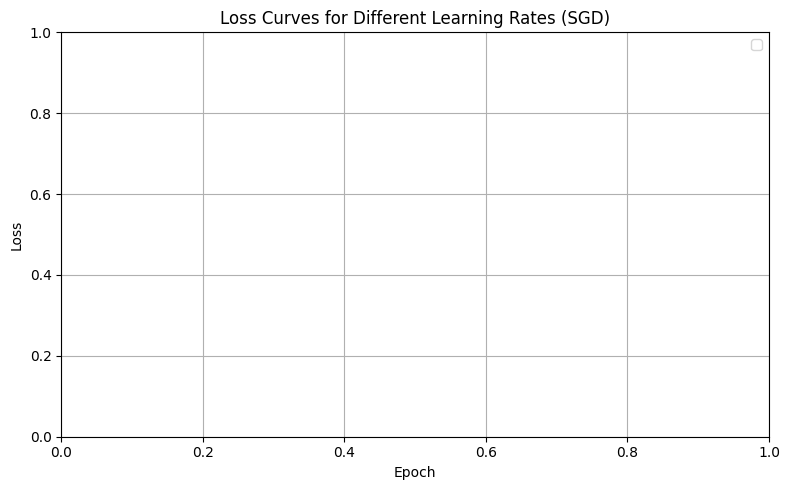

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# Load dataset (if not already loaded)
# --------------------------------------------------
# df = pd.read_csv('your_dataset.csv')

# --------------------------------------------------
# Check available columns
# --------------------------------------------------
print("Columns in dataset:")
print(df.columns.tolist())

# --------------------------------------------------
# Set target column
# Replace with the actual target in your dataset
# --------------------------------------------------
target_column = 'PE'

# --------------------------------------------------
# Create features and target
# --------------------------------------------------
y = df[target_column]

# Keep only numeric features and remove target
X = df.select_dtypes(include='number').drop(columns=[target_column], errors='ignore')

print("\nFeature matrix shape:", X.shape)
print("Target vector shape :", y.shape)

# --------------------------------------------------
# Train/Test Split
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,

)

# --------------------------------------------------
# Feature Scaling
# --------------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------------
# Train MLPs with different learning rates
# --------------------------------------------------
learning_rates = [0.001, 0.01, 0.2]
loss_curves = {}

for lr in learning_rates:

    mlp = MLPClassifier(
        hidden_layer_sizes=(20,),
        solver='sgd',
        learning_rate_init=lr,
        max_iter=200,
        random_state=42
    )
try:
    mlp.fit(X_train, y_train)
    print("Training successful")
    print("Loss curve length:", len(mlp.loss_curve_))
    loss_curves[lr] = mlp.loss_curve_

except Exception as e:
    print("Training failed:")
    print(type(e).__name__)
    print(e)

# --------------------------------------------------
# Plot all loss curves
# --------------------------------------------------
plt.figure(figsize=(8, 5))

for lr, losses in loss_curves.items():
    plt.plot(losses, linewidth=2, label=f'lr = {lr}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves for Different Learning Rates (SGD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Comment
# --------------------------------------------------
# lr = 0.001 : Too slow. Loss decreases gradually.
# lr = 0.01  : Good. Fast and stable convergence.
# lr = 0.2   : Usually unstable. Loss may oscillate or diverge.

# --------------------------------------------------
# Comment
# --------------------------------------------------
# lr = 0.001 : Too slow (loss decreases gradually)
# lr = 0.01  : Good learning rate (fast, stable convergence)
# lr = 0.2   : Often unstable (loss may oscillate or diverge)

#3. The bias–variance trade-off via model complexity

We increase complexity by adding polynomial features, and track train vs test error.

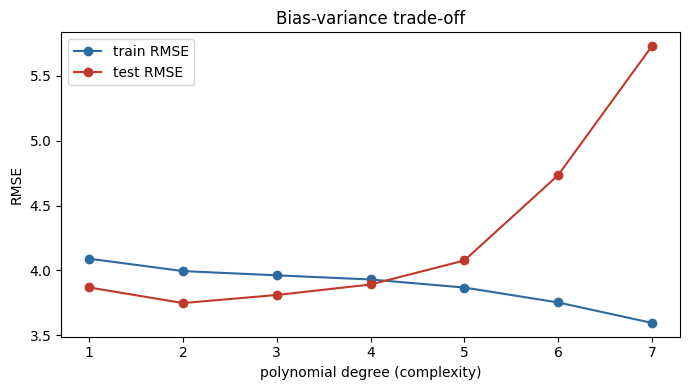

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [38]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN vs TEST ERROR ACROSS POLYNOMIAL DEGREES
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')

#### 🧪 EXERCISE 3 — Find the sweet spot
1. From `te_err`, find the degree with the **lowest test RMSE** (`np.argmin`).
2. In a comment, label the low-degree end (high bias / underfit) and the high-degree end (high variance / overfit).

In [39]:
# Find degree with lowest test RMSE
best_idx = np.argmin(te_err)

best_degree = degrees[best_idx]
best_rmse = te_err[best_idx]

print("Best polynomial degree:", best_degree)
print("Lowest test RMSE:", round(best_rmse, 4))

# Comment:
# Low-degree models (left side of the curve) typically have high bias and
# underfit because they are too simple to capture the pattern in the data.
#
# High-degree models (right side of the curve) typically have high variance
# and overfit because they start fitting noise in the training data.
#
# The degree with the lowest test RMSE provides the best bias-variance tradeoff.

Best polynomial degree: 2
Lowest test RMSE: 3.749


#4. Regularisation — Ridge & Lasso

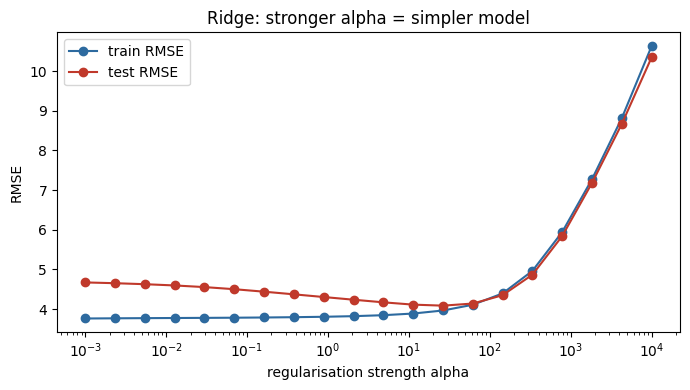

In [40]:
# -----------------------------------------------------------
# 🔹 4A. ON A DELIBERATELY OVER-COMPLEX MODEL, VARY ALPHA
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-3, 4, 20)
tr, te = [], []
for a in alphas:
    m = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=a))
    m.fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('regularisation strength alpha'); ax.set_ylabel('RMSE')
ax.set_title('Ridge: stronger alpha = simpler model'); ax.legend()
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Lasso drops features
1. Fit a `Lasso(alpha=0.1)` on the **degree-1** features (just AT, V, AP, RH after scaling).
2. Print its coefficients.
3. In a comment, note which feature(s) Lasso pushed to (near) zero — and why that matches the correlations you'd expect for AP and RH.

In [41]:
from sklearn.linear_model import Lasso
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# --------------------------------------------------
# Degree-1 features only
# --------------------------------------------------
features = ['AT', 'V', 'AP', 'RH']

X = df[features]
y = df['PE']   # replace if your target column has a different name

# --------------------------------------------------
# Scale features
# --------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# Fit Lasso
# --------------------------------------------------
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_scaled, y)

# --------------------------------------------------
# Print coefficients
# --------------------------------------------------
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso.coef_
})

print(coef_df)

# Optional: sorted view
print("\nSorted by |coefficient|:")
print(
    coef_df.assign(abs_coef=coef_df['Coefficient'].abs())
           .sort_values('abs_coef', ascending=False)
           .drop(columns='abs_coef')
)

  Feature  Coefficient
0      AT   -17.010844
1       V    -3.194174
2      AP     0.284765
3      RH     0.470553

Sorted by |coefficient|:
  Feature  Coefficient
0      AT   -17.010844
1       V    -3.194174
3      RH     0.470553
2      AP     0.284765


#5. Diagnose with learning curves

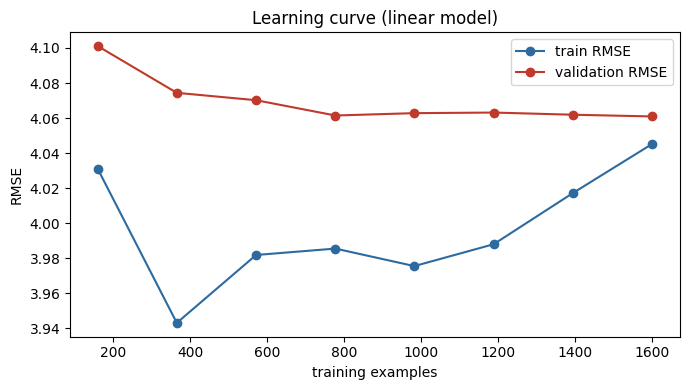

Both errors high and close => more bias-limited than variance-limited here.


In [42]:
# -----------------------------------------------------------
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')

#### 🧪 EXERCISE 5 — Interpret two scenarios
1. Re-draw the learning curve for a **degree-6** polynomial model.
2. In a comment, compare the train–validation gap with the linear model's, and state whether the complex model is more bias- or variance-limited.

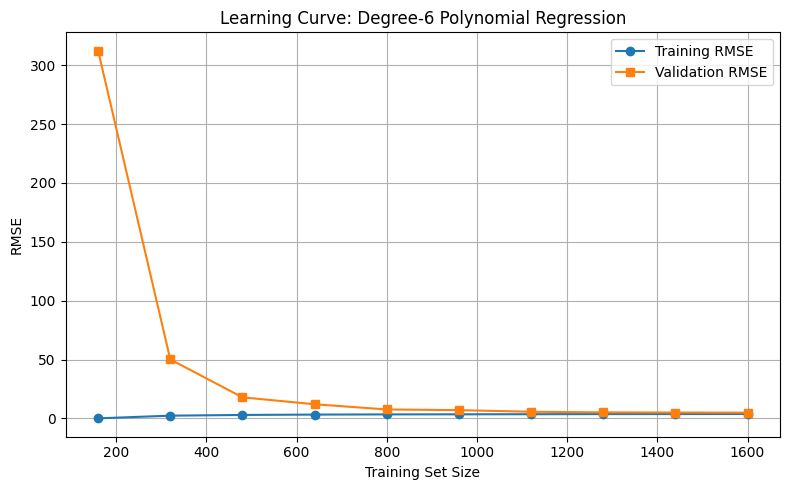

Final Training RMSE : 3.705
Final Validation RMSE: 4.8317
Train-Validation Gap : 1.1267


In [43]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

# --------------------------------------------------
# Degree-6 Polynomial Model
# --------------------------------------------------
poly6_model = Pipeline([
    ('poly', PolynomialFeatures(degree=6, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# --------------------------------------------------
# Learning Curve
# --------------------------------------------------
train_sizes, train_scores, val_scores = learning_curve(
    poly6_model,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Convert negative RMSE to positive RMSE
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_rmse,
         marker='o', label='Training RMSE')

plt.plot(train_sizes, val_rmse,
         marker='s', label='Validation RMSE')

plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve: Degree-6 Polynomial Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Print final gap
# --------------------------------------------------
gap = val_rmse[-1] - train_rmse[-1]

print("Final Training RMSE :", round(train_rmse[-1], 4))
print("Final Validation RMSE:", round(val_rmse[-1], 4))
print("Train-Validation Gap :", round(gap, 4))

#6. Put it together — the best-generalising model

In [44]:
# -----------------------------------------------------------
# 🔹 6A. CHOOSE COMPLEXITY + REGULARISATION BY CROSS-VALIDATION
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
best = None
for d in [1, 2, 3]:
    for a in [0.1, 1, 10, 100]:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a))
        score = -cross_val_score(m, X_train, y_train, cv=5,
                                 scoring='neg_root_mean_squared_error').mean()
        if best is None or score < best[0]:
            best = (score, d, a)
print(f'best CV RMSE {best[0]:.2f} at degree={best[1]}, alpha={best[2]}')

best CV RMSE 4.04 at degree=2, alpha=1


In [49]:
best_degree = 2
best_alpha = 0.1

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Test RMSE:", round(test_rmse, 4))
print("Test R²:", round(test_r2, 4))

Test RMSE: 3.749
Test R²: 0.9654


#### 🧪 EXERCISE 6 — Lock it in
1. Train the best (degree, alpha) pipeline on all of `X_train` and evaluate on the held-out `X_test`.
2. Compare its test RMSE & R² with the Section-1 baseline.
3. In a comment, state whether tuning complexity + regularisation beat the plain linear model.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

best_degree = 2
best_alpha = 0.1

# Recalculate baseline values from Section 1A
# Assuming X_train, y_train, X_test, y_test are already defined in the notebook's global scope
lin = LinearRegression().fit(X_train, y_train)
pred_baseline = lin.predict(X_test)
baseline_rmse = mean_squared_error(y_test, pred_baseline) ** 0.5
baseline_r2 = r2_score(y_test, pred_baseline)

# --------------------------------------------------
# Train final model using best hyperparameters
# --------------------------------------------------
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])

final_model.fit(X_train, y_train)

# --------------------------------------------------
# Test-set evaluation
# --------------------------------------------------
y_pred = final_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Best Degree :", best_degree)
print("Best Alpha  :", best_alpha)

print("\nFinal Model Performance")
print("-----------------------")
print("Test RMSE :", round(test_rmse, 4))
print("Test R²   :", round(test_r2, 4))

# --------------------------------------------------
# Compare with baseline
# --------------------------------------------------
print("\nBaseline Linear Regression")
print("--------------------------")
print("RMSE :", round(baseline_rmse, 4))
print("R²   :", round(baseline_r2, 4))

print("\nImprovement")
print("-----------")
print("RMSE Change :", round(baseline_rmse - test_rmse, 4))
print("R² Change   :\n", round(test_r2 - baseline_r2, 4))

Best Degree : 2
Best Alpha  : 0.1

Final Model Performance
-----------------------
Test RMSE : 3.749
Test R²   : 0.9654

Baseline Linear Regression
--------------------------
RMSE : 3.869
R²   : 0.9632

Improvement
-----------
RMSE Change : 0.1199
R² Change   :
 0.0022


#📘 Summary

| Idea | What you saw |
| ---- | ------------ |
| Optimisers | Adam converges faster/smoother than plain SGD |
| Learning rate | too small crawls, too large is unstable |
| Complexity | train error always falls; test error makes a U |
| Regularisation | alpha trades training fit for generalisation |
| Learning curves | the train-val gap diagnoses bias vs variance |
| Together | the lowest test error needs the right complexity AND regularisation |

**Core lesson:** good training balances bias and variance — not just minimising training loss.

**Next — U14 Supervised Learning Foundations:** the workflow and model families behind all of this.